In [1]:
import pandas as pd

from Chord import Chord
from Rule import Rule
from collections import defaultdict
import pitchtypes as pt
from probabilistic_model import ProbabilisticModel
from itertools import product
import torch 
from Environment import Environment
from Helpers import get_possible_intervals, get_qualities, get_possible_rhs_from_str, get_applicable_rules, evaluate_tree_from_dict
from TreeNode import TreeNode, build_tree_from_dict
from DQN import train_on_batch, ReplayBuffer, train_model, DQN, DQNWithTransformer
import numpy as np
from sklearn.model_selection import train_test_split

import random

In [2]:
def evaluate_tree_from_dict(tree, prob_dict,parent_label=None):
    applied_rules = []
    log_probs = 0
    if tree.get('children'):
        children = tree['children']
        
        if len(children) == 2:
            chord1 = Chord(children[0]['label'])
            chord2 = Chord(children[1]['label'])
            parent = Chord(tree['label'])
            parent_quality = parent.quality

            if chord1.distance_to(parent) == 0:
                chord1interval = 0
                chord2interval = chord1.distance_to(chord2)
            elif chord2.distance_to(parent) == 0:
                chord1interval = chord2.distance_to(chord1)
                chord2interval = 0
            else:
                # If neither child matches the parent, use distance from parent
                chord1interval = chord1.distance_to(parent)
                chord2interval = chord2.distance_to(parent)

            child_intervals = [str(chord1interval), str(chord2interval)]
            child_qualities = [chord1.quality, chord2.quality]

            rule = Rule(parent_quality, child_intervals, child_qualities)
            applied_rules.append(rule)

        # Recursively gather rules from children
        for child in children:
            applied_rules.extend(evaluate_tree_from_dict(child, prob_dict,tree['label'])[0])

    for rule in applied_rules:
        rule_hash = rule.make_hashable()
        if rule_hash in prob_dict:
            log_probs += np.log(prob_dict[rule_hash])
        else:
            log_probs += np.log(1e-10)
    return applied_rules, log_probs


In [3]:
import pickle

# Load the model from the file
with open('dqn_model2.pkl', 'rb') as file:
    unpickled_model = pickle.load(file)

print("Model has been successfully unpickled.")

Model has been successfully unpickled.


In [4]:
data = pd.read_json('../eda/JazzHarmonyTreebank/treebank.json')
trees_data = data[data['trees'].notna()]['trees']
ccts = [x[0]['complete_constituent_tree'] for x in list(trees_data)]
data_with_trees = data[data['trees'].notna()]
data_with_trees['cct'] = ccts
data_with_trees = data[data['trees'].notna()]
data_with_trees['cct'] = ccts
leaf_chords = [[i.chord.label for i in build_tree_from_dict(x).get_leaves()] for x in ccts]
data_with_trees['leaf_chords'] = leaf_chords

/var/folders/pw/xb1fvg_55f91jlbx6wgbwqn80000gn/T/ipykernel_41178/2148688738.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_with_trees['cct'] = ccts
/var/folders/pw/xb1fvg_55f91jlbx6wgbwqn80000gn/T/ipykernel_41178/2148688738.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_with_trees['cct'] = ccts
/var/folders/pw/xb1fvg_55f91jlbx6wgbwqn80000gn/T/ipykernel_41178/2148688738.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_ind

In [5]:
p_model = ProbabilisticModel()
p_model.fit(ccts)
prob_dict = p_model.prob_dict
rules = [Rule.unhash(i) for i in prob_dict.keys()]
chords_dataset = list(data['chords'])
# chords_dataset = [chord for chord in chords_dataset if len(chord) <= 20]  

In [6]:
train_data, test_data = train_test_split(data_with_trees, test_size=0.2, random_state=42)

In [35]:
test_data.iloc[index]

title                                                  Lady Bird
measures       [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...
beats          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...
chords         [C^7, C^7, Fm7, Bb7, C^7, C^7, Bbm7, Eb7, Ab^7...
composers                                          Dameron, Tadd
year                                                        1947
meter                         {'numerator': 4, 'denominator': 4}
key                                                            C
turnaround                                                   3.0
trees          [{'open_constituent_tree': {'label': 'C^7', 'c...
comments                             no applied chords annotated
cct            {'label': 'C^7', 'children': [{'label': 'C^7',...
leaf_chords    [C^7, C^7, Fm7, Bb7, C^7, C^7, Bbm7, Eb7, Ab^7...
Name: 69, dtype: object

In [38]:
index = 22

In [43]:
sorted_prob_dict = dict(sorted(prob_dict.items(), key=lambda item: item[1], reverse=True))

In [44]:
sorted_prob_dict

{(('child_intervals', ('0', '0')),
  ('child_qualities', ('minor', 'minor')),
  ('parent_quality', 'minor')): 0.4410143329658214,
 (('child_intervals', ('7', '0')),
  ('child_qualities', ('major', 'minor')),
  ('parent_quality', 'minor')): 0.3263506063947078,
 (('child_intervals', ('0', '0')),
  ('child_qualities', ('major', 'major')),
  ('parent_quality', 'major')): 0.29694473051836595,
 (('child_intervals', ('0', '0')),
  ('child_qualities', ('sus', 'sus')),
  ('parent_quality', 'sus')): 0.2857142857142857,
 (('child_intervals', ('7', '0')),
  ('child_qualities', ('major', 'major')),
  ('parent_quality', 'major')): 0.25060075523515274,
 (('child_intervals', ('7', '0')),
  ('child_qualities', ('major', 'unknown')),
  ('parent_quality', 'unknown')): 0.1896551724137931,
 (('child_intervals', ('7', '0')),
  ('child_qualities', ('minor', 'major')),
  ('parent_quality', 'major')): 0.1826295914864401,
 (('child_intervals', ('10', '0')),
  ('child_qualities', ('sus', 'sus')),
  ('parent_qual

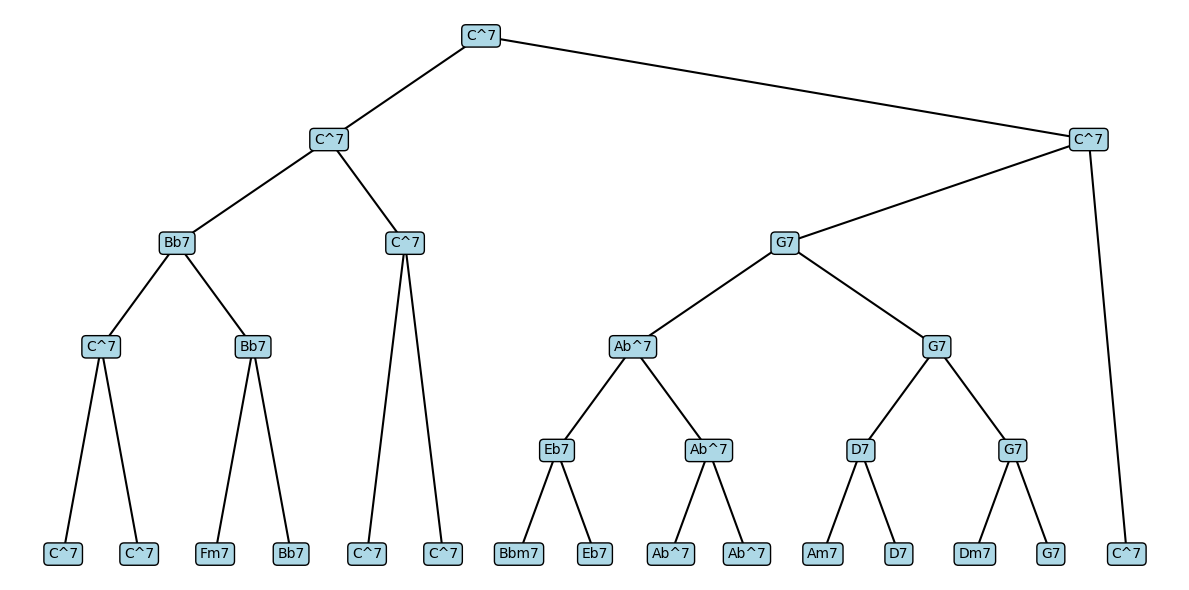

In [39]:
build_tree_from_dict(test_data.iloc[index]['cct']).visualize()

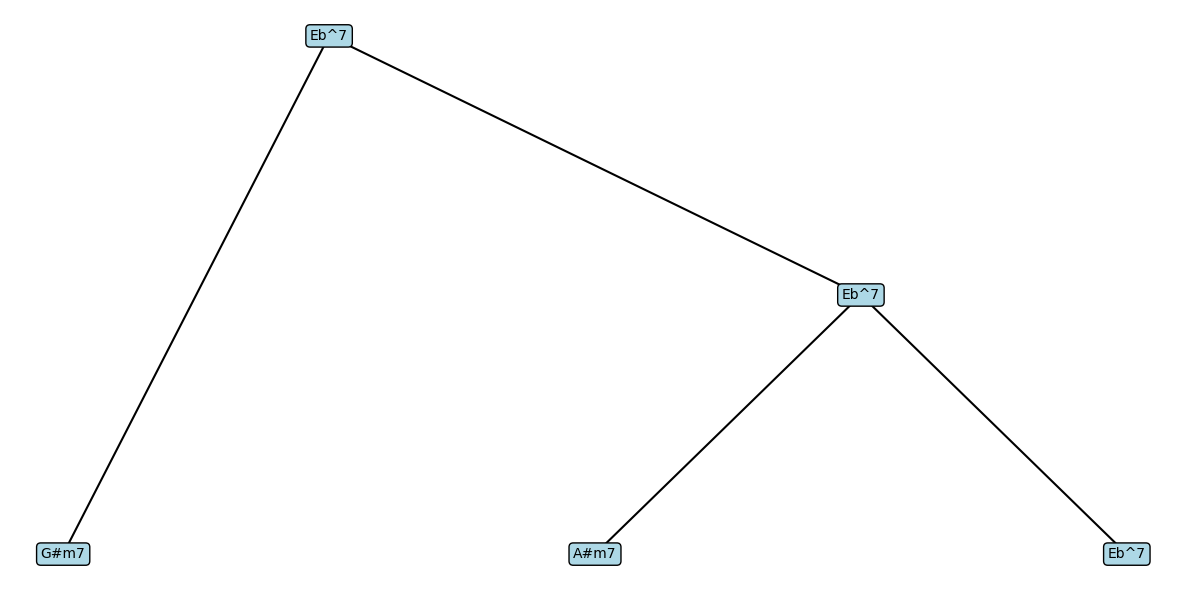

In [41]:
env = Environment(["G#m7","A#m7","Eb^7"],rules,prob_dict)
env.add_model(unpickled_model)
env.nn_simulate()
env.current_nodes[0].visualize()

In [40]:
test_data.iloc[index]

title                                                  Lady Bird
measures       [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...
beats          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...
chords         [C^7, C^7, Fm7, Bb7, C^7, C^7, Bbm7, Eb7, Ab^7...
composers                                          Dameron, Tadd
year                                                        1947
meter                         {'numerator': 4, 'denominator': 4}
key                                                            C
turnaround                                                   3.0
trees          [{'open_constituent_tree': {'label': 'C^7', 'c...
comments                             no applied chords annotated
cct            {'label': 'C^7', 'children': [{'label': 'C^7',...
leaf_chords    [C^7, C^7, Fm7, Bb7, C^7, C^7, Bbm7, Eb7, Ab^7...
Name: 69, dtype: object

In [13]:
max_depth_nn = []
max_depth_greedy = []
max_depth_ground_truth = []
max_depth_random = []

total_nn = []
total_greedy = []
total_ground_truth = []
total_random = []

tree_edit_nn = []
tree_edit_greedy = []
tree_edit_random = []

In [14]:
for i in range(len(test_data)):
    env = Environment(test_data.iloc[i]['leaf_chords'], rules, prob_dict)
    env.add_model(unpickled_model)
    env.nn_simulate()
    max_depth_nn.append(env.current_nodes[0].get_total_depth())
    total_nn.append(env.evaluate_tree())

    env2 = Environment(test_data.iloc[i]['leaf_chords'], rules, prob_dict)
    env2.simulate_greedy_baseline()
    max_depth_greedy.append(env2.current_nodes[0].get_total_depth())
    total_greedy.append(env2.evaluate_tree())


    env3 = Environment(test_data.iloc[i]['leaf_chords'], rules, prob_dict)
    env3.simulate_random_baseline()
    max_depth_random.append(env3.current_nodes[0].get_total_depth())
    total_random.append(env3.evaluate_tree())


    max_depth_ground_truth.append(build_tree_from_dict(test_data.iloc[i]['cct']).get_total_depth())
    total_ground_truth.append(evaluate_tree_from_dict(test_data.iloc[i]['cct'],prob_dict)[1])

    tree_edit_nn.append(env.current_nodes[0].tree_edit_distance(build_tree_from_dict(test_data.iloc[i]['cct'])))
    tree_edit_greedy.append(env2.current_nodes[0].tree_edit_distance(build_tree_from_dict(test_data.iloc[i]['cct'])))

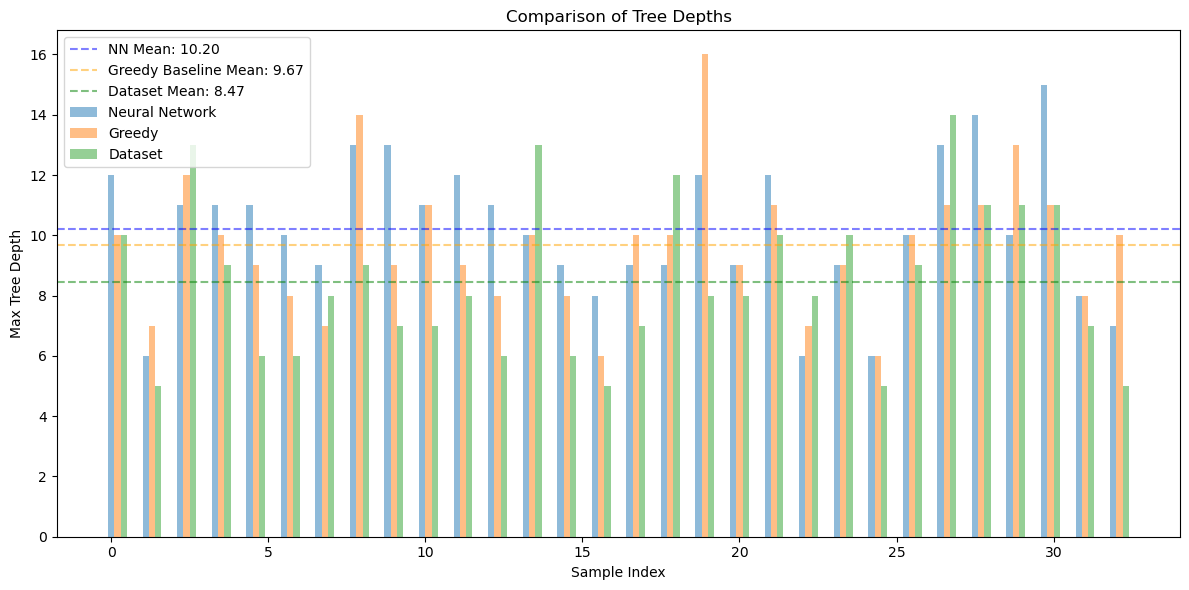

In [15]:
import numpy as np

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Define the width of each bar and the spacing between groups
bar_width = 0.2
group_spacing = 0.5

# Calculate the x positions for each group
x = np.arange(len(total_nn)) * (3 * bar_width + group_spacing)

# Plot the bars for each method
plt.bar(x, max_depth_nn, alpha=0.5, label='Neural Network', width=bar_width)
plt.bar(x + bar_width, max_depth_greedy, alpha=0.5, label='Greedy', width=bar_width)
plt.bar(x + 2 * bar_width, max_depth_ground_truth, alpha=0.5, label='Dataset', width=bar_width)
# plt.bar(x + 3 * bar_width, max_depth_random, alpha=0.5, label='Dataset', width=bar_width)

# Add labels and title
plt.xlabel('Sample Index')
plt.ylabel('Max Tree Depth')
plt.title('Comparison of Tree Depths')

# Add mean lines
plt.axhline(y=np.mean(max_depth_nn), color='blue', linestyle='--', alpha=0.5, label=f"NN Mean: {np.mean(max_depth_nn):.2f}")
plt.axhline(y=np.mean(max_depth_greedy), color='orange', linestyle='--', alpha=0.5, label=f"Greedy Baseline Mean: {np.mean(max_depth_greedy):.2f}")
plt.axhline(y=np.mean(max_depth_ground_truth), color='green', linestyle='--', alpha=0.5, label=f"Dataset Mean: {np.mean(max_depth_ground_truth):.2f}")
# plt.axhline(y=np.mean(max_depth_random), color='green', linestyle='--', alpha=0.5, label=f"Dataset Mean: {np.mean(max_depth_random):.2f}")

# Adjust layout and add legend
plt.tight_layout()
plt.legend()
plt.show()

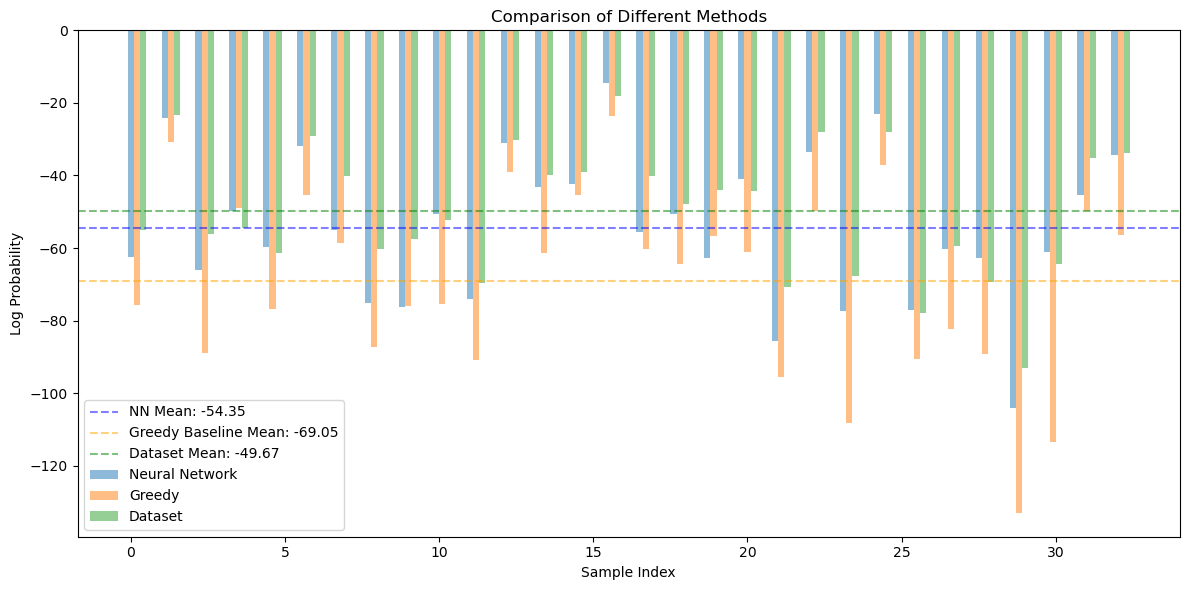

In [16]:
import numpy as np

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Define the width of each bar and the spacing between groups
bar_width = 0.2
group_spacing = 0.5

# Calculate the x positions for each group
x = np.arange(len(total_nn)) * (3 * bar_width + group_spacing)

# Plot the bars for each method
plt.bar(x, total_nn, alpha=0.5, label='Neural Network', width=bar_width)
plt.bar(x + bar_width, total_greedy, alpha=0.5, label='Greedy', width=bar_width)
plt.bar(x + 2 * bar_width, total_ground_truth, alpha=0.5, label='Dataset', width=bar_width)
# plt.bar(x + 3 * bar_width, total_random, alpha=0.5, label='Dataset', width=bar_width)

# Add labels and title
plt.xlabel('Sample Index')
plt.ylabel('Log Probability')
plt.title('Comparison of Different Methods')

# Add mean lines
plt.axhline(y=np.mean(total_nn), color='blue', linestyle='--', alpha=0.5, label=f"NN Mean: {np.mean(total_nn):.2f}")
plt.axhline(y=np.mean(total_greedy), color='orange', linestyle='--', alpha=0.5, label=f"Greedy Baseline Mean: {np.mean(total_greedy):.2f}")
plt.axhline(y=np.mean(total_ground_truth), color='green', linestyle='--', alpha=0.5, label=f"Dataset Mean: {np.mean(total_ground_truth):.2f}")
# plt.axhline(y=np.mean(total_random), color='green', linestyle='--', alpha=0.5, label=f"RandomMean: {np.mean(total_random):.2f}")

# Adjust layout and add legend
plt.tight_layout()
plt.legend()
plt.show()

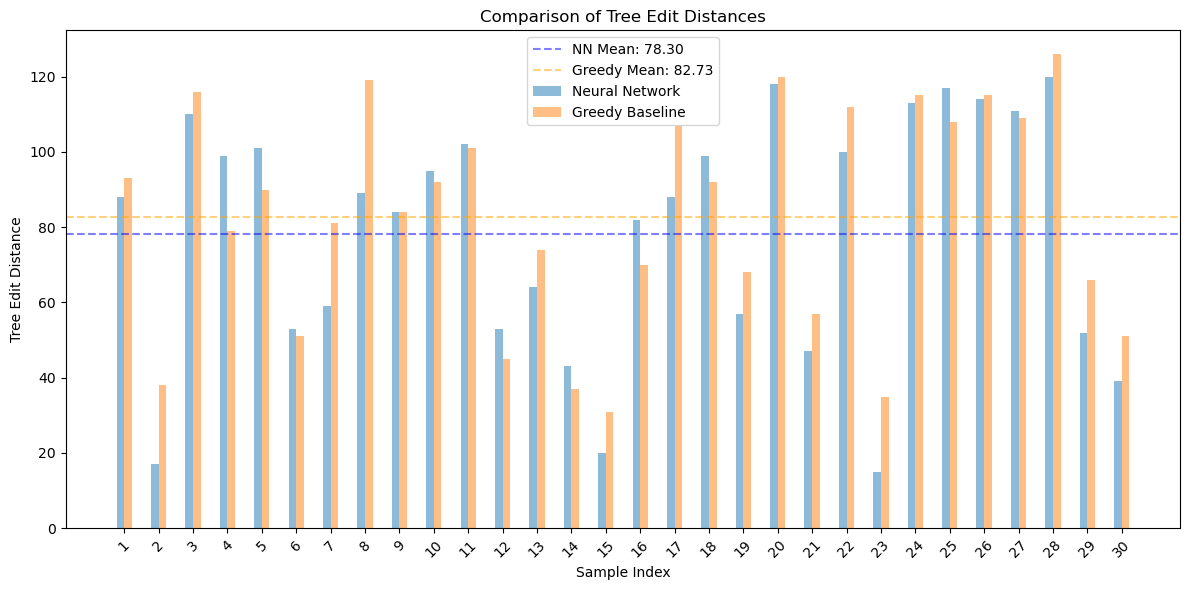

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Example data (replace with your actual values)
# tree_edit_nn = [...]
# tree_edit_greedy = [...]

plt.figure(figsize=(12, 6))

# Bar width and group spacing
bar_width = 0.2
group_spacing = 0.5

# X positions for each sample
x = np.arange(len(tree_edit_nn)) * (2 * bar_width + group_spacing)

# Plot bars
plt.bar(x, tree_edit_nn, width=bar_width, alpha=0.5, label='Neural Network')
plt.bar(x + bar_width, tree_edit_greedy, width=bar_width, alpha=0.5, label='Greedy Baseline')

# Mean lines
plt.axhline(y=np.mean(tree_edit_nn), color='blue', linestyle='--', alpha=0.5,
            label=f"NN Mean: {np.mean(tree_edit_nn):.2f}")
plt.axhline(y=np.mean(tree_edit_greedy), color='orange', linestyle='--', alpha=0.5,
            label=f"Greedy Mean: {np.mean(tree_edit_greedy):.2f}")

# Labels and formatting
plt.xlabel('Sample Index')
plt.ylabel('Tree Edit Distance')
plt.title('Comparison of Tree Edit Distances')
plt.xticks(x + bar_width / 2, [f'{i+1}' for i in range(len(tree_edit_nn))], rotation=45)

plt.legend()
plt.tight_layout()
plt.show()


In [27]:
training_loss = []
with open('training.txt', 'r') as f:
    training_lines = f.readlines()

# Example: print the first few lines to check the content
for line in training_lines:
    num = line.strip()[-6:]
    # print(num)
    training_loss.append(float(num))

In [33]:
import numpy as np

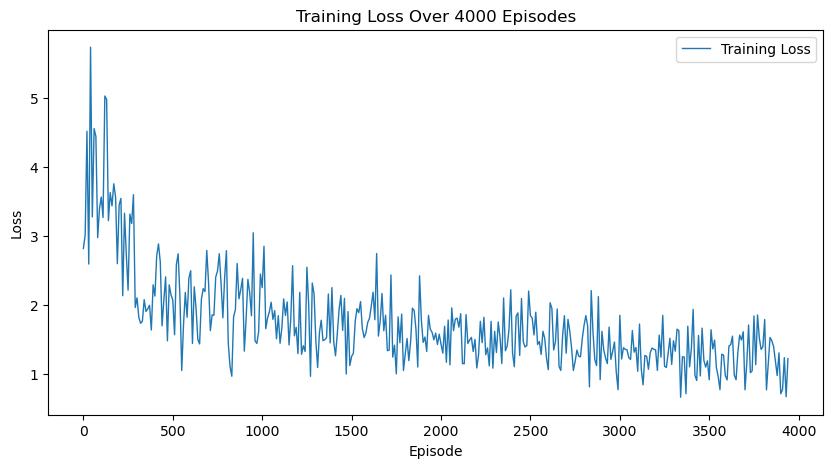

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(np.arange(len(training_loss)) * 10, training_loss, label='Training Loss', linewidth=1)
plt.xlabel('Episode')
plt.ylabel('Loss')
plt.title('Training Loss Over 4000 Episodes')
plt.legend()
plt.show()
